In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns


In [2]:
df=pd.read_csv("Algerian_forest_fires_dataset_UPDATE_clean.csv")
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region,encod_Classes
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0,0


In [3]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region', 'encod_Classes'],
      dtype='object')

In [4]:
df['Classes'] = df['encod_Classes']


In [5]:
df.drop(['day' ,'month' , 'year','encod_Classes'] , axis=1 ,inplace=True)

In [6]:
x=df.drop(['FWI'],axis=1)
y=df['FWI']
x

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1


In [7]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

<Axes: >

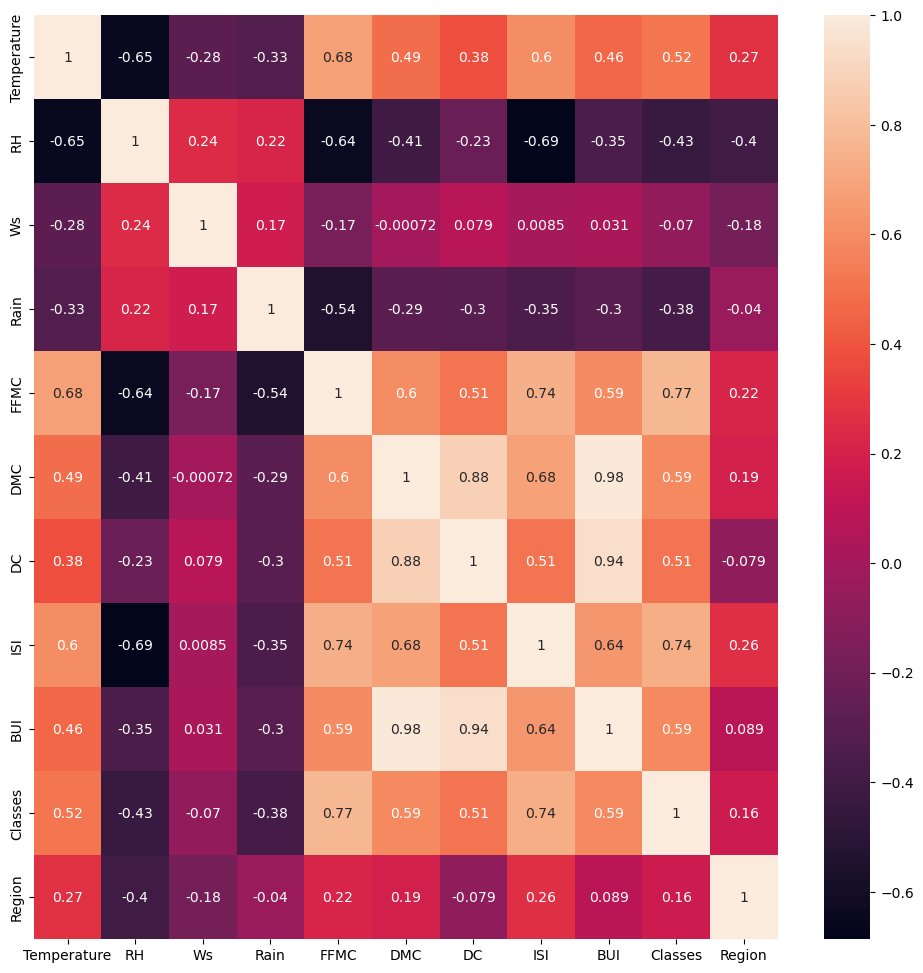

In [8]:
# features selection base on corelation
# we remove those column that highly co-related

# check the corelation
plt.figure(figsize=(12,12))
sns.heatmap(x.corr(),annot=True)

In [9]:
x.corr().shape

(11, 11)

In [10]:
def coorelation(dataset , threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[ i , j] > threshold):
                col_name = corr_matrix.columns[i]

                col_corr.add(col_name)
    return col_corr

high_correlation = coorelation(x , 0.85)
x.drop(high_correlation ,axis=1,inplace=True)


In [11]:
# train test split
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y ,train_size=0.75, random_state=42)


In [12]:
x_train.shape

(182, 9)

In [13]:
# feature scalling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

Text(0.5, 1.0, 'x_train after scaling')

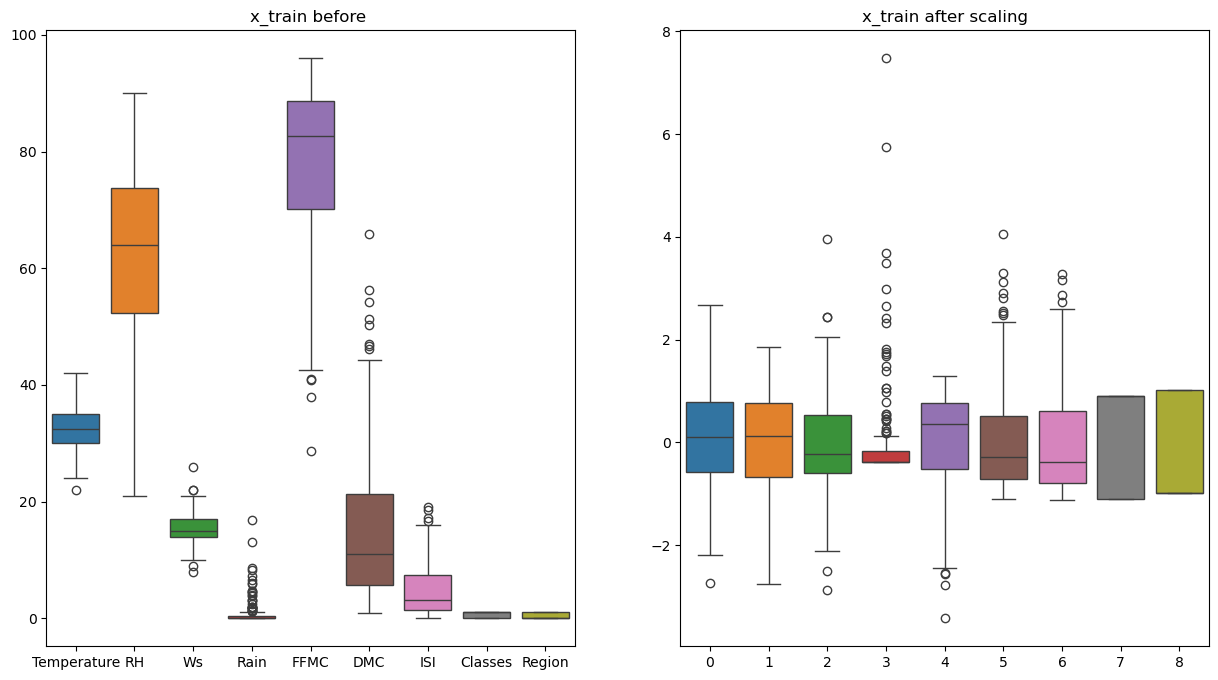

In [14]:
# box plot for understand standarscaler
plt.figure(figsize= (15 , 8))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title("x_train before ")
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)
plt.title("x_train after scaling")

## Linear Regression Model

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error ,r2_score
regression = LinearRegression()
regression.fit(x_train_scaled , y_train)

y_pred = regression.predict(x_test_scaled)
mae = mean_absolute_error(y_test , y_pred)
scour = r2_score(y_test , y_pred)

In [16]:
print(mae)
print(scour)

0.5468236465249973
0.9847657384266952


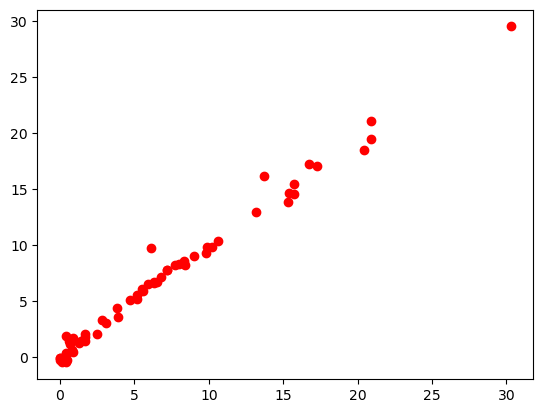

In [17]:
plt.scatter(y_test , y_pred , c='r')


1.1331759949144087
0.9492020263112388


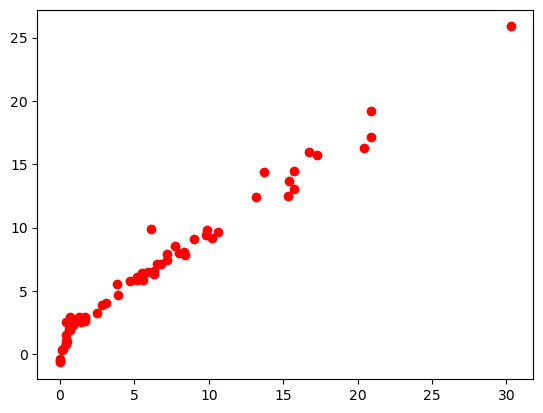

In [18]:
# Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error ,r2_score
lasso_regression = Lasso()
lasso_regression.fit(x_train_scaled , y_train)

y_pred = lasso_regression.predict(x_test_scaled)
mae = mean_absolute_error(y_test , y_pred)
scour = r2_score(y_test , y_pred)
print(mae)
print(scour)
plt.scatter(y_test , y_pred , c='r')


Mean absolute error 0.5642305340105692
R2 Score 0.9842993364555513


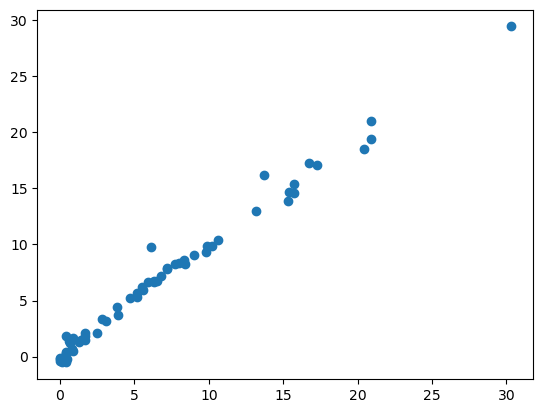

In [21]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(x_train_scaled,y_train)
y_pred=ridgecv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

0.5642305340105692
0.9842993364555513


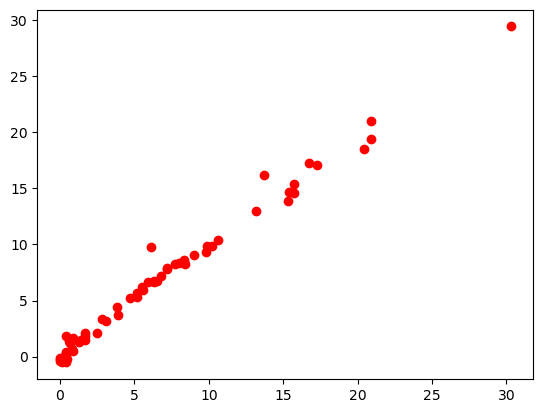

In [22]:
# Ridge regression

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error ,r2_score
Ridge_regression = Ridge()
Ridge_regression.fit(x_train_scaled , y_train)

y_pred = Ridge_regression.predict(x_test_scaled)
mae = mean_absolute_error(y_test , y_pred)
scour = r2_score(y_test , y_pred)
print(mae)
print(scour)
plt.scatter(y_test , y_pred , c='r')


1.8822353634896
0.8753460589519703


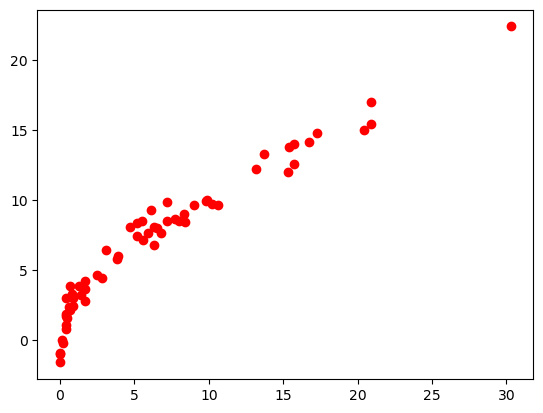

In [23]:
# Elasticnet Regression
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error ,r2_score
ElasticNet_regression = ElasticNet()
ElasticNet_regression.fit(x_train_scaled , y_train)

y_pred = ElasticNet_regression.predict(x_test_scaled)
mae = mean_absolute_error(y_test , y_pred)
scour = r2_score(y_test , y_pred)
print(mae)
print(scour)
plt.scatter(y_test , y_pred , c='r')


Mean absolute error 0.6575946731430902
R2 Score 0.9814217587854941


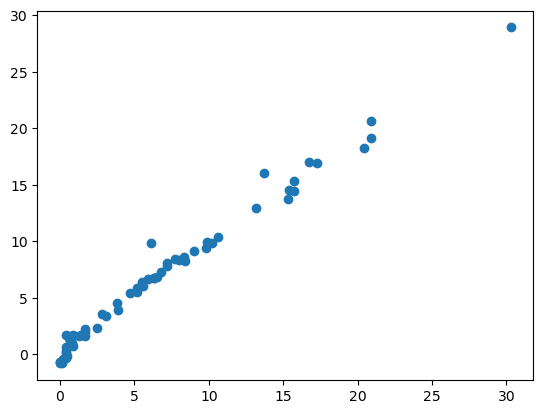

In [26]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(x_train_scaled,y_train)
y_pred=elasticcv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

In [28]:
# save the model by pickle
StandardScaler()

,copy,True
,with_mean,True
,with_std,True


In [29]:
import pickle
pickle.dump(scaler , open('scaler.pkl','wb'))
pickle.dump(Ridge_regression , open('ridge_regression.pkl','wb'))